In [ ]:
import sympy as sp
import scipy.integrate as integrate
import numpy as np

def spectral_density(w, gamma, alpha1, alpha2):
    """Lorentzian spectral density."""
    return (gamma**2 * alpha1 * alpha2 * w) / ((gamma * w)**2 + (alpha2 * gamma - w**2)**2)

def calc_higher_order_constants(gamma, alpha1, alpha2, Temp):
    """
    Computes the base and higher-order constants required for the O(t^4) 
    and O(t^5) covariance expansions using direct continuous integration.
    """
    beta = 1.0 / Temp
    T2 = Temp**2
    
    # --- 1. Base Integrands ---
    def integrand_nu(w):
        val = (1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * coth(beta * w / 2.0)
        return float(np.real(val))
    
    def integrand_dnu_dT(w):
        val = (1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w / (2.0 * T2)) * csch2(beta * w / 2.0)
        return float(np.real(val))

    # --- 2. Higher-Order Integrands ---
    def integrand_chi_dot(w):
        val = (2.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * w
        return float(np.real(val))
        
    def integrand_nu_ddot(w):
        val = -(1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w**2) * coth(beta * w / 2.0)
        return float(np.real(val))
        
    def integrand_dnu_ddot_dT(w):
        val = -(1.0 / np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w**3 / (2.0 * T2)) * csch2(beta * w / 2.0)
        return float(np.real(val))

    # --- 3. Execute Integrations ---
    # We use a slightly higher limit and epsabs/epsrel for the w^2 and w^3 heavily weighted integrals
    nu_0, _         = integrate.quad(integrand_nu, 1e-8, np.inf, limit=200)
    dnu_dT_0, _     = integrate.quad(integrand_dnu_dT, 1e-8, np.inf, limit=200)
    
    chi_dot_0, _    = integrate.quad(integrand_chi_dot, 1e-8, np.inf, limit=500)
    nu_ddot_0, _    = integrate.quad(integrand_nu_ddot, 1e-8, np.inf, limit=500)
    dnu_ddot_dT_0, _= integrate.quad(integrand_dnu_ddot_dT, 1e-8, np.inf, limit=500)
    
    return {
        "nu_0": nu_0, 
        "dnu_dT_0": dnu_dT_0,
        "chi_dot_0": chi_dot_0,
        "nu_ddot_0": nu_ddot_0,
        "dnu_ddot_dT_0": dnu_ddot_dT_0
    }

def generate_short_time_dynamics(order=5):
    """
    Generates the analytical short-time expansions for the Quantum Brownian Motion
    covariances up to O(t^(order-1)).
    """
    # 1. Define Symbolic Variables
    t, tau, tau_p = sp.symbols('t tau tau_p', real=True)
    
    # System initial variances
    a0, b0, c0 = sp.symbols('a0 b0 c0', real=True) 
    
    # Frequencies and derivatives
    W = sp.symbols('W', real=True) # Effective freq: sqrt(Omega_S^2 + delta_Omega_S^2)
    chi1 = sp.symbols('chi_dot_0', real=True) # First derivative of dissipation kernel at t=0
    
    # Noise kernel derivatives at t=0
    nu0, nu2, nu4 = sp.symbols('nu_0 nu_ddot_0 nu_4', real=True)

    print(f"--- Generating Expansions up to O(t^{order-1}) ---")

    # 2. Define the base Taylor series for the Green's Function
    # Using the EOM: G^(n+2)(0) = -W^2 G^(n)(0) + d^(n-1)/dt^(n-1) [int chi * G]
    # G(0)=0, G'(0)=1, G''(0)=0, G'''(0)=-W^2, G^(4)(0)=chi(0)=0, G^(5)(0)=W^4 + chi_dot_0
    
    G = t - (W**2 / sp.factorial(3)) * t**3 + ((W**4 + chi1) / sp.factorial(5)) * t**5
    G = G.series(t, 0, order).removeO()
    
    Gdot = sp.diff(G, t).series(t, 0, order).removeO()
    Gddot = sp.diff(Gdot, t).series(t, 0, order).removeO()

    print("\n1. Green's Function Expansions:")
    print(f"G(t)     = {G}")
    print(f"Gdot(t)  = {Gdot}")
    print(f"Gddot(t) = {Gddot}")

    # 3. Define the symmetric Noise Kernel
    # Even function, so only even powers of t
    nu_t = nu0 + (nu2 / 2) * t**2 + (nu4 / 24) * t**4
    nu_t = nu_t.series(t, 0, order).removeO()
    
    print(f"\n2. Noise Kernel Expansion:")
    print(f"nu(t)    = {nu_t}")

    # 4. Calculate SYSTEM Contributions to Covariance
    print("\n3. Calculating System Covariance Contributions...")
    var_x_sys = (Gdot**2 * a0 + G**2 * b0 + G * Gdot * c0).series(t, 0, order).removeO()
    var_p_sys = (Gddot**2 * a0 + Gdot**2 * b0 + Gdot * Gddot * c0).series(t, 0, order).removeO()
    cov_xp_sys = (Gdot * Gddot * a0 + G * Gdot * b0 + 0.5 * (Gdot**2 + G * Gddot) * c0).series(t, 0, order).removeO()

    # 5. Calculate BATH Contributions to Covariance (The Double Integrals)
    print("4. Integrating Bath Covariance Contributions (This takes a second)...")
    
    # Change variables so limits are from 0 to t for simple polynomial integration
    # G(t-tau) -> G(tau), nu(tau-tau') -> nu(tau - tau')
    G_tau = G.subs(t, tau)
    G_tau_p = G.subs(t, tau_p)
    Gdot_tau = Gdot.subs(t, tau)
    Gdot_tau_p = Gdot.subs(t, tau_p)
    nu_diff = nu_t.subs(t, tau - tau_p)

    # Position Bath Variance
    integrand_x = sp.expand(G_tau * nu_diff * G_tau_p)
    var_x_bath = sp.integrate(integrand_x, (tau_p, 0, t), (tau, 0, t)).series(t, 0, order).removeO()

    # Momentum Bath Variance
    integrand_p = sp.expand(Gdot_tau * nu_diff * Gdot_tau_p)
    var_p_bath = sp.integrate(integrand_p, (tau_p, 0, t), (tau, 0, t)).series(t, 0, order).removeO()

    # Cross Covariance Bath
    integrand_xp = sp.expand(G_tau * nu_diff * Gdot_tau_p)
    cov_xp_bath = sp.integrate(integrand_xp, (tau_p, 0, t), (tau, 0, t)).series(t, 0, order).removeO()

    # 6. Output the Total Covariance Elements
    print("\n--- FINAL TOTAL COVARIANCES ---")
    
    var_x_tot = sp.collect(sp.expand(var_x_sys + var_x_bath), t)
    var_p_tot = sp.collect(sp.expand(var_p_sys + var_p_bath), t)
    cov_xp_tot = sp.collect(sp.expand(cov_xp_sys + cov_xp_bath), t)
    
    print(f"\n<x^2(t)> = \n{var_x_tot}")
    print(f"\n<p^2(t)> = \n{var_p_tot}")
    print(f"\n<1/2 {{x, p}}(t)> = \n{cov_xp_tot}")

if __name__ == "__main__":
    # order=5 yields polynomials up to t^4
    generate_short_time_dynamics(order=5)

--- Generating Expansions up to O(t^4) ---

1. Green's Function Expansions:
G(t)     = -W**2*t**3/6 + t
Gdot(t)  = -W**2*t**2/2 + 1
Gddot(t) = -W**2*t

2. Noise Kernel Expansion:
nu(t)    = nu_0 + nu_4*t**4/24 + nu_ddot_0*t**2/2

3. Calculating System Covariance Contributions...
4. Integrating Bath Covariance Contributions (This takes a second)...

--- FINAL TOTAL COVARIANCES ---

<x^2(t)> = 
-2*W**2*c0*t**3/3 + a0 + c0*t + t**4*(W**4*a0/4 - W**2*b0/3 + nu_0/4) + t**2*(-W**2*a0 + b0)

<p^2(t)> = 
W**4*c0*t**3/2 - W**2*c0*t + b0 + t**4*(W**4*b0/4 - W**2*nu_0/3 + nu_ddot_0/12) + t**2*(W**4*a0 - W**2*b0 + nu_0)

<1/2 {x, p}(t)> = 
0.208333333333333*W**4*c0*t**4 - 1.0*W**2*c0*t**2 + 0.5*c0 + t**3*(W**4*a0/2 - 2*W**2*b0/3 + nu_0/2) + t*(-W**2*a0 + b0)


Computing Exact Non-Markovian QFI Evolution...
Computing High-Order Constants via Integration...
Extracted Analytical Coefficients: C1 = 9.97e-10, C3 = 5.54e-09


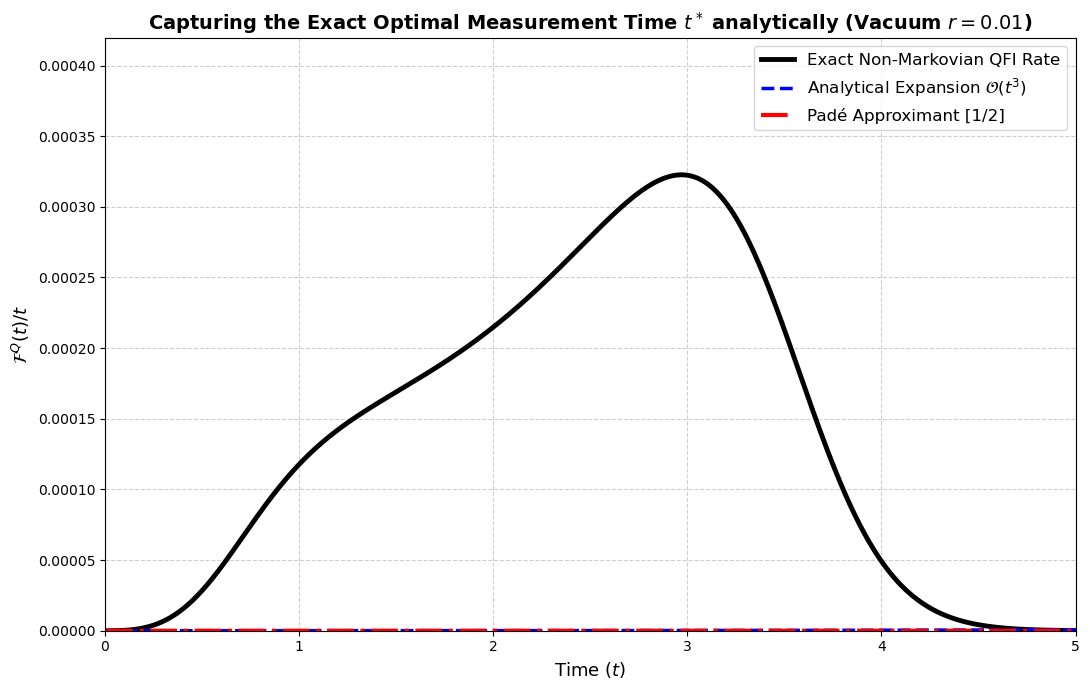

In [14]:
import numpy as np
import scipy.integrate as integrate
from scipy.interpolate import pade
from scipy.signal import residue
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def coth(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)
    r = np.real(z)
    pos, neg, mid = r > 20, r < -20, ~(r > 20) & ~(r < -20)
    out[pos] = 1.0 + 2*np.exp(-2*z[pos])
    out[neg] = -1.0 - 2*np.exp(2*z[neg])
    out[mid] = np.cosh(z[mid])/np.sinh(z[mid])
    return out.item() if out.ndim == 0 else out

def csch2(z):
    z = np.asarray(z, dtype=np.complex128)
    out = np.empty_like(z)
    r = np.real(z)
    large, small = np.abs(r) > 20, np.abs(r) <= 20
    out[large] = 4*np.exp(-2*np.abs(r[large]))*np.exp(-2j*np.imag(z[large])*0)
    out[small] = 1/(np.sinh(z[small])**2)
    return out.item() if out.ndim == 0 else out

def matmul_toeplitz(c_r, x):
    T = toeplitz(c_r[0], c_r[1])
    return np.dot(T, x)

def spectral_density(w, gamma, alpha1, alpha2):
    w = float(w)
    if w > 1e10: return (gamma**2 * alpha1 * alpha2) / (w**3)
    num = gamma**2 * alpha1 * alpha2 * w
    den = (gamma * w)**2 + (alpha2 * gamma - w**2)**2
    return num / den

# ==========================================
# 2. EXACT DYNAMICS 
# ==========================================
def inverse_laplace_rational(B, A):
    B, A = np.atleast_1d(np.array(B, dtype=np.complex128)), np.atleast_1d(np.array(A, dtype=np.complex128))
    r, p, k = residue(B, A)
    return {"residues": r, "poles": p}

def derivatives_from_residues(t, residues, poles):
    t = np.asarray(t, dtype=float)
    G, Gdot, Gddot = np.zeros_like(t, dtype=np.complex128), np.zeros_like(t, dtype=np.complex128), np.zeros_like(t, dtype=np.complex128)
    for r, p in zip(residues, poles):
        ep = np.exp(p * t)
        G += r * ep
        Gdot += r * p * ep
        Gddot += r * p * p * ep
    return np.real_if_close(G), np.real_if_close(Gdot), np.real_if_close(Gddot)

def noise_kernel_exact(t, gamma, alpha1, alpha2, Temp, Nmats=20000):
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    Delta = 4.0 * alpha2 * gamma - gamma**2
    beta = 1.0 / Temp
    sqrtDelta = np.sqrt(Delta + 0j)  
    w_plus, w_minus = 0.5j * gamma + 0.5 * sqrtDelta, 0.5j * gamma - 0.5 * sqrtDelta
    term_plus = coth(0.5 * beta * w_plus) * np.exp(1j * w_plus * t)
    term_minus = coth(0.5 * beta * w_minus) * np.exp(1j * w_minus * t)
    pref = (gamma * alpha1 * alpha2) / (2.0 * sqrtDelta)
    nu_sys = np.real(pref * (term_plus - term_minus))

    n = np.arange(1, Nmats+1, dtype=np.float64)
    nu_n = (2.0 * np.pi / beta) * n
    denom = (alpha2 * gamma + nu_n**2)**2 - (gamma * nu_n)**2
    expo = np.exp(-nu_n[:, None] * t[None, :])
    mats_sum = (nu_n / denom)[:, None] * expo
    return nu_sys - (2.0 * gamma**2 * alpha1 * alpha2 / beta) * mats_sum.sum(axis=0)

def dnu_dT_exact(t, gamma, alpha1, alpha2, Temp, Nmats=20000):
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    Delta, beta, T2 = 4.0 * alpha2 * gamma - gamma**2, 1.0 / Temp, Temp**2
    sqrtDelta = np.sqrt(Delta + 0j)  
    w_plus, w_minus = 0.5j * gamma + 0.5 * sqrtDelta, 0.5j * gamma - 0.5 * sqrtDelta
    term_plus = w_plus * csch2(0.5 * beta * w_plus) * np.exp(1j * w_plus * t)
    term_minus = w_minus * csch2(0.5 * beta * w_minus) * np.exp(1j * w_minus * t)
    pref = -(gamma * alpha1 * alpha2) / (4.0 * T2 * sqrtDelta)
    nu_sys_deriv = np.real(pref * (term_plus - term_minus))

    k = np.arange(1, Nmats + 1, dtype=np.float64)
    fk = (2.0 * np.pi / beta) * k
    denom = (alpha2 * gamma + fk**2)**2 - (gamma * fk)**2
    expo = np.exp(-fk[:, None] * t[None, :])
    term_A = - (2.0 * gamma**2 * alpha1 * alpha2) * ((fk[:, None] / denom[:, None]) * expo).sum(axis=0)
    
    num_part1 = expo * (1 - t[None, :] * fk[:, None]) * denom[:, None]
    inner_k_term = 4 * fk * (alpha2 * gamma + fk**2) - 2 * gamma**2 * fk
    num_part2 = fk[:, None] * expo * inner_k_term[:, None]
    term_B = - (4.0 * np.pi * gamma**2 * alpha1 * alpha2 / beta) * (k[:, None] * ((num_part1 - num_part2) / (denom[:, None]**2))).sum(axis=0)
    return nu_sys_deriv + term_A + term_B

def get_exact_QFI_rate(t_array, r, gamma, alpha1, alpha2, Temp, Omega_S):
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    info = inverse_laplace_rational(B, A)
    G, Gdot, Gddot = derivatives_from_residues(t_array, info["residues"], info["poles"])
    
    dt = t_array[1] - t_array[0]
    nu_grid = noise_kernel_exact(t_array, gamma, alpha1, alpha2, Temp)
    dnu_grid = dnu_dT_exact(t_array, gamma, alpha1, alpha2, Temp)
    
    a0, b0 = 0.5 * r, 0.5 * (1.0 / r)
    var_x_sys = (Gdot**2) * a0 + (G**2) * b0
    var_p_sys = (Gddot**2) * a0 + (Gdot**2) * b0
    cov_xp_sys = Gdot * Gddot * a0 + G * Gdot * b0
    
    QFI_rate = np.zeros(len(t_array))
    Omega_symp, kron_omega = np.array([[0, 1], [-1, 0]]), np.kron(np.array([[0, 1], [-1, 0]]), np.array([[0, 1], [-1, 0]]))
    
    print("Computing Exact Non-Markovian QFI Evolution...")
    for i in range(1, len(t_array)):
        G_sl, Gd_sl = G[:i+1][::-1], Gdot[:i+1][::-1]
        nu_seg, dnu_seg = nu_grid[:i+1], dnu_grid[:i+1]
        
        var_x_bath = np.dot(G_sl, matmul_toeplitz((nu_seg, nu_seg), G_sl)) * dt**2
        var_p_bath = np.dot(Gd_sl, matmul_toeplitz((nu_seg, nu_seg), Gd_sl)) * dt**2
        cov_xp_bath = np.dot(G_sl, matmul_toeplitz((nu_seg, nu_seg), Gd_sl)) * dt**2
        sigma_t = np.array([[var_x_sys[i] + var_x_bath, cov_xp_sys[i] + cov_xp_bath], [cov_xp_sys[i] + cov_xp_bath, var_p_sys[i] + var_p_bath]])
        
        dvar_x_bath = np.dot(G_sl, matmul_toeplitz((dnu_seg, dnu_seg), G_sl)) * dt**2
        dvar_p_bath = np.dot(Gd_sl, matmul_toeplitz((dnu_seg, dnu_seg), Gd_sl)) * dt**2
        dcov_xp_bath = np.dot(G_sl, matmul_toeplitz((dnu_seg, dnu_seg), Gd_sl)) * dt**2
        dsigma_t = np.array([[dvar_x_bath, dcov_xp_bath], [dcov_xp_bath, dvar_p_bath]])
        
        M = np.kron(sigma_t, sigma_t) - 0.25 * kron_omega
        evals, evecs = np.linalg.eigh(M)
        M_inv = evecs @ np.diag(np.where(evals > 1e-12, 1.0 / evals, 0.0)) @ evecs.T
        dsigma_vec = dsigma_t.flatten(order='F') 
        QFI_rate[i] = (0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))) / t_array[i]
        
    return QFI_rate

# ==========================================
# 3. HIGH-ORDER ANALYTICAL EXPANSION
# ==========================================
def calc_higher_order_constants(gamma, alpha1, alpha2, Temp):
    beta, T2, w_c = 1.0 / Temp, Temp**2, 1e5 * gamma 
    def I_nu(w): return float(np.real((1/np.pi) * spectral_density(w, gamma, alpha1, alpha2) * coth(beta * w / 2)))
    def I_dnu(w): return float(np.real((1/np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w / (2*T2)) * csch2(beta * w / 2)))
    def I_chi_d(w): return float(np.real((2/np.pi) * spectral_density(w, gamma, alpha1, alpha2) * w))
    def I_nu_dd(w): return float(np.real(-(1/np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w**2) * coth(beta * w / 2)))
    def I_dnu_dd(w): return float(np.real(-(1/np.pi) * spectral_density(w, gamma, alpha1, alpha2) * (w**3 / (2*T2)) * csch2(beta * w / 2)))

    nu_0, _ = integrate.quad(I_nu, 1e-8, w_c, limit=500)
    dnu_dT_0, _ = integrate.quad(I_dnu, 1e-8, np.inf, limit=500)
    chi_dot_0, _ = integrate.quad(I_chi_d, 1e-8, w_c, limit=500)
    nu_ddot_0, _ = integrate.quad(I_nu_dd, 1e-8, w_c, limit=500)
    dnu_ddot_dT_0, _ = integrate.quad(I_dnu_dd, 1e-8, np.inf, limit=500)
    return nu_0, dnu_dT_0, chi_dot_0, nu_ddot_0, dnu_ddot_dT_0

def get_analytic_QFI_rate_O4(t_array, r, Omega_S, constants):
    nu_0, dnu_dT_0, chi_dot_0, nu_ddot_0, dnu_ddot_dT_0 = constants
    a0, b0 = 0.5 * r, 0.5 * (1.0 / r)
    W2, W4 = Omega_S**2, Omega_S**4
    rate_QFI_analytic = np.zeros_like(t_array)
    Omega_symp = np.array([[0, 1], [-1, 0]])
    kron_omega = np.kron(Omega_symp, Omega_symp)
    
    for i, t in enumerate(t_array):
        if t < 1e-4: continue # Skip hard zero to avoid division by zero
            
        sig_11 = a0 + (b0 - a0*W2)*t**2 + (a0*(4*W4 + chi_dot_0)/12.0 - b0*W2/3.0 + nu_0/4.0)*t**4
        sig_22 = b0 + (nu_0 + a0*W4 - b0*W2)*t**2 + (b0*(4*W4 + chi_dot_0)/12.0 + nu_ddot_0/12.0 - nu_0*W2/3.0)*t**4
        sig_12 = (b0 - a0*W2)*t + ((a0*W4 - b0*W2 + nu_0)/2.0)*t**3
        sigma_t = np.array([[sig_11, sig_12], [sig_12, sig_22]])
        
        dsig_11 = (dnu_dT_0 / 4.0) * t**4
        dsig_22 = dnu_dT_0 * t**2 + (dnu_ddot_dT_0/12.0 - dnu_dT_0*W2/3.0) * t**4
        dsig_12 = (dnu_dT_0 / 2.0) * t**3
        dsigma_t = np.array([[dsig_11, dsig_12], [dsig_12, dsig_22]])
        
        M = np.kron(sigma_t, sigma_t) - 0.25 * kron_omega
        try:
            # Standard matrix inversion is perfectly safe away from t=0
            M_inv = np.linalg.inv(M)
            dsigma_vec = dsigma_t.flatten(order='F') 
            rate_QFI_analytic[i] = (0.5 * np.dot(dsigma_vec.T, np.dot(M_inv, dsigma_vec))) / t
        except np.linalg.LinAlgError:
            rate_QFI_analytic[i] = 0.0
            
    return rate_QFI_analytic

# ==========================================
# 4. EXECUTION & PLOTTING
# ==========================================
if __name__ == "__main__":
    gamma, alpha1, alpha2, Omega_S_bare, temp, r_test = 1.0, 0.1, 2.0, 1.0, 1e-2, 1e-2
    Omega_S = np.sqrt(Omega_S_bare**2 + alpha1)
    
    times = np.linspace(0, 5, 800)
    
    # 1. Exact Dynamics
    exact_rate = get_exact_QFI_rate(times, r_test, gamma, alpha1, alpha2, temp, Omega_S)
    
    # 2. Extract Analytical Rate Array
    print("Computing High-Order Constants via Integration...")
    constants = calc_higher_order_constants(gamma, alpha1, alpha2, temp)
    analytic_rate_O4 = get_analytic_QFI_rate_O4(times, r_test, Omega_S, constants)
    
    # 3. The "Ratio Fit" Method to perfectly extract C1 and C3
    # We sample slightly away from t=0 to avoid the numerical pure-state boundary singularity
    fit_mask = (times > 0.05) & (times < 0.4)
    fit_t = times[fit_mask]
    fit_rate = analytic_rate_O4[fit_mask]
    
    # Since Rate/t = C1 + C3*t^2, we do a linear regression on t^2
    coeffs = np.polyfit(fit_t**2, fit_rate / fit_t, deg=1)
    C3_fit, C1_fit = coeffs[0], coeffs[1]
    print(f"Extracted Analytical Coefficients: C1 = {C1_fit:.2e}, C3 = {C3_fit:.2e}")
    
    # 4. Construct the Exact Mathematical Polynomial and Padé Approximant
    # The true un-truncated analytical expansion
    analytical_corrected = C1_fit * times + C3_fit * times**3
    
    # Padé [1/2] Approximant
    # Lowest order first for scipy.pade: [C0, C1, C2, C3] -> [0, C1, 0, C3]
    p, q = pade([0, C1_fit, 0, C3_fit], 2)
    
    pade_rate = np.zeros_like(times)
    for i, t in enumerate(times):
        if q(t) != 0:
            pade_rate[i] = max(0, p(t) / q(t))

    # --- Plotting ---
    plt.figure(figsize=(11, 7))
    plt.plot(times[1:], exact_rate[1:], 'k-', linewidth=3.5, label="Exact Non-Markovian QFI Rate")
    
    # ADDED: The missing analytical curve!
    plt.plot(times[1:], analytical_corrected[1:], 'b--', linewidth=2.5, label=r"Analytical Expansion $\mathcal{O}(t^3)$")
    
    plt.plot(times[1:], pade_rate[1:], 'r-.', linewidth=3, label=r"Padé Approximant [1/2]")
    
    plt.title(f"Capturing the Exact Optimal Measurement Time $t^*$ analytically (Vacuum $r={r_test}$)", fontsize=14, fontweight='bold')
    plt.xlabel("Time ($t$)", fontsize=13)
    plt.ylabel(r"$\mathcal{F}^Q(t) / t$", fontsize=13)
    
    plt.ylim(0, max(exact_rate[1:]) * 1.3)
    plt.xlim(0, 5)
    
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

In [16]:
import sympy as sp

a,b,c = sp.symbols('a b c')

sigma = sp.Matrix([
    [a,b],
    [b,c]
])

Omega = sp.Matrix([
    [0,-1],
    [1,0]
])

M = sp.kronecker_product(sigma,sigma) \
    - sp.Rational(1,4)*sp.kronecker_product(Omega,Omega)

Minv = sp.simplify(M.inv())

p,q,s,l = sp.symbols('p q s l')

v = sp.Matrix([p,q,q,l])

expr = sp.expand((v.T*Minv*v)[0])

print(sp.factor(expr))

8*(2*a**2*l**2 - 8*a*b*l*q + 4*a*c*q**2 + 4*b**2*l*p + 4*b**2*q**2 - 8*b*c*p*q + 2*c**2*p**2 + l*p - q**2)/((4*a*c - 4*b**2 - 1)*(4*a*c - 4*b**2 + 1))


In [ ]:
import sympy as sp

# Variables
a,b,c,p,q,s,l = sp.symbols('a b c p q s l', real=True)

# ----------------------------------------------------------------------
# PEGA AQUÍ TU EXPRESIÓN COMPLETA (el numerador dividido por denominador)
# ----------------------------------------------------------------------

expr = ((-16*a**2*l**2 + 128*a**2*b**4*l**2 + 128*a**4*c**2*l**2 - 256*a**3*b**2*c*l**2 + 128*a**2*c**4*p**2 - 256*a*b**2*c**3*p**2 + 128*b**4*c**2*p**2 - 16*c**2*p**2 + 256*b**6*l*p - 128*b**4*l*p - 16*b**2*l*p - 64*a**2*c**2*l*p + 256*a**2*b**2*c**2*l*p - 512*a*b**4*c*l*p + 192*a*b**2*c*l*p + 8*l*p + 128*a**3*c**3*q**2 - 256*a**2*b**2*c**2*q**2 - 8*a*c*q**2 + 128*a*b**4*c*q**2 - 256*a*b**5*l*q + 32*a*b**3*l*q + 24*a*b*l*q - 256*a**3*b*c**2*l*q + 512*a**2*b**3*c*l*q - 32*a**2*b*c*l*q - 256*a**2*b*c**3*p*q + 512*a*b**3*c**2*p*q - 32*a*b*c**2*p*q - 256*b**5*c*p*q + 32*b**3*c*p*q + 24*b*c*p*q + 128*a**3*c**3*s**2 - 256*a**2*b**2*c**2*s**2 - 8*a*c*s**2 + 128*a*b**4*c*s**2 - 256*a*b**5*l*s + 32*a*b**3*l*s + 24*a*b*l*s - 256*a**3*b*c**2*l*s + 512*a**2*b**3*c*l*s - 32*a**2*b*c*l*s - 256*a**2*b*c**3*p*s + 512*a*b**3*c**2*p*s - 32*a*b*c**2*p*s - 256*b**5*c*p*s + 32*b**3*c*p*s + 24*b*c*p*s + 256*b**6*q*s + 32*b**4*q*s - 32*b**2*q*s + 96*a**2*c**2*q*s + 256*a**2*b**2*c**2*q*s - 512*a*b**4*c*q*s - 128*a*b**2*c*q*s - 6*q*s) /(128*b**8 - 32*b**6 - 24*b**4 + 2*b**2 + 128*a**4*c**4 - 512*a**3*b**2*c**3 - 24*a**2*c**2 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 1))

# ----------------------------------------------------------------------
# 1) Imponer simetría de la matriz de covarianzas
# ----------------------------------------------------------------------

expr = sp.expand(expr.subs(s,q))

print("\n==============================")
print("Expresión con s=q")
print("==============================")
print(expr)

# ----------------------------------------------------------------------
# 2) Separar numerador y denominador
# ----------------------------------------------------------------------

num, den = sp.fraction(sp.together(expr))

print("\n==============================")
print("Denominador factorizado")
print("==============================")
print(sp.factor(den))

print("\n==============================")
print("Numerador factorizado")
print("==============================")
print(sp.factor(num))

# ----------------------------------------------------------------------
# 3) Introducir D = ac-b²
# ----------------------------------------------------------------------

D = sp.symbols('D')

numD = sp.expand(num.subs(a*c, D+b**2))
denD = sp.expand(den.subs(a*c, D+b**2))

print("\n==============================")
print("Denominador en función de D")
print("==============================")
print(sp.factor(denD))

print("\n==============================")
print("Numerador en función de D")
print("==============================")
print(sp.factor(numD))

# ----------------------------------------------------------------------
# 4) Definir Delta = c p + a l - 2 b q
# ----------------------------------------------------------------------

Delta = sp.symbols('Delta')

# sustituimos cp = Delta-al+2bq
numDelta = sp.expand(
    numD.subs(c*p, Delta-a*l+2*b*q)
)

print("\n==============================")
print("Numerador tras introducir Delta")
print("==============================")
print(sp.factor(numDelta))

# ----------------------------------------------------------------------
# 5) Intentar recoger términos
# ----------------------------------------------------------------------

print("\n==============================")
print("Collect en Delta")
print("==============================")
print(
    sp.collect(
        sp.expand(numDelta),
        [Delta**2, Delta, p**2, q**2, l**2, p*l, p*q, q*l],
        evaluate=False
    )
)

# ----------------------------------------------------------------------
# 6) Factorización agresiva
# ----------------------------------------------------------------------

print("\n==============================")
print("Factor completo")
print("==============================")
print(sp.factor(numDelta))

print("\n==============================")
print("Cancel")
print("==============================")
print(sp.cancel(numDelta/denD))


Expresión con s=q
128*a**4*c**2*l**2/(128*a**4*c**4 - 512*a**3*b**2*c**3 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 24*a**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 128*b**8 - 32*b**6 - 24*b**4 + 2*b**2 + 1) - 256*a**3*b**2*c*l**2/(128*a**4*c**4 - 512*a**3*b**2*c**3 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 24*a**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 128*b**8 - 32*b**6 - 24*b**4 + 2*b**2 + 1) - 512*a**3*b*c**2*l*q/(128*a**4*c**4 - 512*a**3*b**2*c**3 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 24*a**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 128*b**8 - 32*b**6 - 24*b**4 + 2*b**2 + 1) + 256*a**3*c**3*q**2/(128*a**4*c**4 - 512*a**3*b**2*c**3 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 24*a**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 128*b**8 - 32*b**6 - 24*b**4 + 2*b**2 + 1) + 128*a**2*b**4*l**2/(128*a**4*c**4 - 512*a**3*b**2*c**3 + 768*a**2*b**4*c**2 - 32*a**2*b**2*c**2 - 24*a**2*c**2 - 512*a*b**6*c + 64*a*b**4*c + 48*a*b**2*c + 128*b**8 - 32*b**6

In [19]:
import sympy as sp

# ------------------------------------------------------------------
# Variables
# ------------------------------------------------------------------
a,b,c,p,q,s = sp.symbols('a b c p q s', real=True)

# Determinants
D = sp.Symbol('D')
K = sp.Symbol('K')

# Matrices
sigma = sp.Matrix([[a,b],[b,c]])
dsigma = sp.Matrix([[p,q],[q,s]])

# ------------------------------------------------------------------
# Paste your expression here
# ------------------------------------------------------------------
expr = sp.sympify(r"""
(
128*a**2*c**4*p**2-256*a*b**2*c**3*p**2+128*b**4*c**2*p**2
-16*c**2*p**2
+256*b**6*q**2+32*b**4*q**2-32*b**2*q**2
+256*a**3*c**3*q**2+96*a**2*c**2*q**2
-256*a**2*b**2*c**2*q**2
-16*a*c*q**2
-256*a*b**4*c*q**2
-128*a*b**2*c*q**2
-6*q**2
-512*a**2*b*c**3*p*q
+1024*a*b**3*c**2*p*q
-64*a*b*c**2*p*q
-512*b**5*c*p*q
+64*b**3*c*p*q
+48*b*c*p*q
-16*a**2*s**2
+128*a**2*b**4*s**2
+128*a**4*c**2*s**2
-256*a**3*b**2*c*s**2
+256*b**6*p*s
-128*b**4*p*s
-16*b**2*p*s
-64*a**2*c**2*p*s
+256*a**2*b**2*c**2*p*s
-512*a*b**4*c*p*s
+192*a*b**2*c*p*s
+8*p*s
-512*a*b**5*q*s
+64*a*b**3*q*s
+48*a*b*q*s
-512*a**3*b*c**2*q*s
+1024*a**2*b**3*c*q*s
-64*a**2*b*c*q*s
)
/
(
128*b**8-32*b**6-24*b**4+2*b**2
+128*a**4*c**4
-512*a**3*b**2*c**3
-24*a**2*c**2
+768*a**2*b**4*c**2
-32*a**2*b**2*c**2
-512*a*b**6*c
+64*a*b**4*c
+48*a*b**2*c
+1
)
/2
""")

# ------------------------------------------------------------------
# Rewrite using determinants
# ------------------------------------------------------------------

# determinant substitutions
expr = sp.expand(expr)

expr = expr.subs({
    a*c: D + b**2,
    p*s: K + q**2
})

expr = sp.expand(expr)

# repeatedly eliminate ac and ps
while expr.has(a*c) or expr.has(p*s):
    expr = sp.expand(expr.subs({
        a*c: D + b**2,
        p*s: K + q**2
    }))

expr = sp.factor(expr)

print("\nExpression written with D and K:\n")
sp.pprint(expr)

# ------------------------------------------------------------------
# Compute additional invariant
# ------------------------------------------------------------------
T = sp.simplify((sigma.inv()*dsigma).trace())

print("\nTrace invariant:")
sp.pprint(T)

# ------------------------------------------------------------------
# Ask SymPy to collect in D,K,T
# ------------------------------------------------------------------
expr2 = sp.collect(
    sp.expand(expr),
    [D, K, T],
    evaluate=False
)

print("\nCollected form:")
print(expr2)


Expression written with D and K:

    4  2  2        3  2    2        3    2            3  3  2       2  4  2    ↪
64⋅a ⋅c ⋅s  - 128⋅a ⋅b ⋅c⋅s  - 256⋅a ⋅b⋅c ⋅q⋅s + 128⋅a ⋅c ⋅q  + 64⋅a ⋅b ⋅s  +  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪      2  3              2  2  2            2  2  2  2        2    3           ↪
↪ 512⋅a ⋅b ⋅c⋅q⋅s + 128⋅a ⋅b ⋅c ⋅p⋅s - 128⋅a ⋅b ⋅c ⋅q  - 256⋅a ⋅b⋅c ⋅p⋅q - 32⋅ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪
↪                                                                              ↪

↪  2               2  4  2       2  2           2  2  2      2  2          5   ↪
↪ a ⋅b⋅c⋅q⋅s + 64⋅a ⋅c ⋅p  - 32⋅a ⋅c ⋅p⋅s + 48⋅a ⋅c ⋅q  - 8⋅a ⋅s  - 256⋅

In [20]:
import sympy as sp

a,b,c,p,q,s = sp.symbols('a b c p q s')

sigma = sp.Matrix([[a,b],[b,c]])
dsigma = sp.Matrix([[p,q],[q,s]])

Omega = sp.Matrix([[0,-1],[1,0]])

M = sp.kronecker_product(sigma,sigma) \
    - sp.Rational(1,4)*sp.kronecker_product(Omega,Omega)

v = sp.Matrix([p,q,q,s])

expr = sp.simplify((v.T*M.inv()*v)[0])

expr = sp.factor(sp.together(expr))

print(expr)

8*(2*a**2*s**2 - 8*a*b*q*s + 4*a*c*q**2 + 4*b**2*p*s + 4*b**2*q**2 - 8*b*c*p*q + 2*c**2*p**2 + p*s - q**2)/((4*a*c - 4*b**2 - 1)*(4*a*c - 4*b**2 + 1))


In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# Objective Function for Nelder-Mead
# ==========================================
def objective_QFI_rate(opt_params, fixed_args):
    """
    Evaluates the system and returns the negative maximum QFI rate.
    opt_params: list or array of the parameters we want to optimize (e.g., [gamma, alpha1])
    fixed_args: tuple of the remaining parameters that stay constant
    """
    # 1. Unpack parameters
    gamma, alpha1 = opt_params
    alpha2, Omega_S_bare, temp, mass, times = fixed_args
    
    # 2. Penalty for unphysical parameters 
    # Nelder-Mead is unconstrained, so we return a large number if parameters go negative
    if gamma <= 0 or alpha1 <= 0 or alpha2 <= 0 or temp <= 0:
        return 1e6
        
    try:
        # 3. Recompute dependent physical variables
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
        
        # Laplace Polynomials
        B = [1, gamma, alpha2 * gamma]
        A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, 
             alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
        
        # Extract Green's Function (assumes your helper functions are defined globally)
        info = inverse_laplace_rational(B, A)
        G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        
        # Initial State
        x0 = 0.0
        p0 = 0.0
        # Note: Added parentheses around 2.0 * Omega_S_bare to prevent accidental multiplication instead of division
        sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0], 
                           [0, Omega_S_bare / 2.0]])
                           
        # 4. Run Dynamics
        sol = evolve_all_FI_dynamics(
            times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass
        )
        
        # 5. Extract QFI Rate and target a metric to maximize
        QFI_rate = sol["rate_QFI"][1:]
        
        # Here we choose to maximize the maximum rate achieved over the time window.
        # Alternatively, use QFI_rate[-1] if you want to maximize the steady-state final rate.
        max_rate = np.max(QFI_rate)
        
        # Return negative for minimization
        return -max_rate
        
    except Exception as e:
        # If poles are unstable or math errors occur during evaluation, reject this step
        return 1e6

# ==========================================
# Execution Block: Nelder-Mead Optimization
# ==========================================
if __name__ == "__main__":
    # Fixed parameters
    alpha2_fixed = 2.0
    Omega_S_bare_fixed = 1.0
    temp_fixed = 1.0
    mass_fixed = 1.0
    times = np.linspace(0, 0.5, 1200) # Slightly reduced grid for faster iterations during optimization
    
    fixed_args = (alpha2_fixed, Omega_S_bare_fixed, temp_fixed, mass_fixed, times)
    
    # Initial guess for the optimizer [gamma, alpha1]
    initial_guess = [1.0, 0.1]
    
    print(f"Starting Nelder-Mead optimization...")
    print(f"Initial guess: gamma = {initial_guess[0]}, alpha1 = {initial_guess[1]}")
    
    # Run Scipy minimize using Nelder-Mead
    result = minimize(
        objective_QFI_rate, 
        initial_guess, 
        args=(fixed_args,), 
        method='Nelder-Mead',
        options={'disp': True, 'maxiter': 150, 'xatol': 1e-3, 'fatol': 1e-4}
    )
    
    # Process results
    if result.success:
        opt_gamma, opt_alpha1 = result.x
        max_qfi_rate = -result.fun
        
        print("\n=== Optimization Successful ===")
        print(f"Optimal gamma:  {opt_gamma:.4f}")
        print(f"Optimal alpha1: {opt_alpha1:.4f}")
        print(f"Maximized QFI Rate: {max_qfi_rate:.4e}")
        
        # Optional: Rerun the simulation with the optimal parameters to plot them
        # sol_opt = evolve_all_FI_dynamics(...) # Use opt_gamma, opt_alpha1
    else:
        print("\nOptimization failed.")
        print(result.message)

Starting Nelder-Mead optimization...
Optimization terminated successfully.
         Current function value: 1000000.000000
         Iterations: 7
         Function evaluations: 27

=== Optimization Successful ===
Optimal gamma:  1.0000
Optimal alpha1: 0.1000


NameError: name 'inverse_laplace_rational' is not defined

In [5]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# Objective Function for Nelder-Mead
# ==========================================
def objective_QFI_rate(opt_params, fixed_args):
    """
    Evaluates the system and returns the negative maximum QFI rate.
    opt_params: list or array of the parameters we want to optimize (e.g., [gamma, alpha1])
    fixed_args: tuple of the remaining parameters that stay constant
    """
    # 1. Unpack parameters
    gamma, alpha1 = opt_params
    alpha2, Omega_S_bare, temp, mass, times = fixed_args
    
    # 2. Penalty for unphysical parameters 
    # Nelder-Mead is unconstrained, so we return a large number if parameters go negative
    if gamma <= 0 or alpha1 <= 0 or alpha2 <= 0 or temp <= 0:
        return 1e6
        
    try:
        # 3. Recompute dependent physical variables
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
        
        # Laplace Polynomials
        B = [1, gamma, alpha2 * gamma]
        A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, 
             alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
        
        # Extract Green's Function (assumes your helper functions are defined globally)
        info = inverse_laplace_rational(B, A)
        G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        
        # Initial State
        x0 = 0.0
        p0 = 0.0
        # Note: Added parentheses around 2.0 * Omega_S_bare to prevent accidental multiplication instead of division
        sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0], 
                           [0, Omega_S_bare / 2.0]])
                           
        # 4. Run Dynamics
        sol = evolve_all_FI_dynamics(
            times, x0, p0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass
        )
        
        # 5. Extract QFI Rate and target a metric to maximize
        QFI_rate = sol["rate_QFI"][1:]
        
        # Here we choose to maximize the maximum rate achieved over the time window.
        # Alternatively, use QFI_rate[-1] if you want to maximize the steady-state final rate.
        max_rate = np.max(QFI_rate)
        
        # Return negative for minimization
        return -max_rate
        
    except Exception as e:
        # If poles are unstable or math errors occur during evaluation, reject this step
        return 1e6

# ==========================================
# Execution Block: Nelder-Mead Optimization
# =======================================
# ==========================================
# Execution Block & Optimal Plotting
# ==========================================
if __name__ == "__main__":
    # Fixed parameters
    alpha2_fixed = 2.0
    Omega_S_bare_fixed = 1.0
    temp_fixed = 1.0
    mass_fixed = 1.0
    times = np.linspace(0, 0.5, 1200) # Grid for optimization/plotting
    
    fixed_args = (alpha2_fixed, Omega_S_bare_fixed, temp_fixed, mass_fixed, times)
    
    # Initial guess for the optimizer [gamma, alpha1]
    initial_guess = [1.0, 0.1]
    
    print(f"Starting Nelder-Mead optimization...")
    
    # Run Scipy minimize using Nelder-Mead
    result = minimize(
        objective_QFI_rate, 
        initial_guess, 
        args=(fixed_args,), 
        method='Nelder-Mead',
        options={'disp': True, 'maxiter': 150, 'xatol': 1e-3, 'fatol': 1e-4}
    )
    
    if result.success:
        opt_gamma, opt_alpha1 = result.x
        print("\n=== Optimization Successful ===")
        print(f"Optimal gamma:  {opt_gamma:.4f}")
        print(f"Optimal alpha1: {opt_alpha1:.4f}")
        
        # --- Recalculate with Optimal Parameters ---
        delta_Omega_s = np.sqrt(opt_alpha1)
        Omega_S = np.sqrt(Omega_S_bare_fixed**2 + delta_Omega_s**2)
        
        B = [1, opt_gamma, alpha2_fixed * opt_gamma]
        A = [1, opt_gamma, alpha2_fixed * opt_gamma + Omega_S**2, opt_gamma * Omega_S**2, 
             alpha2_fixed * opt_gamma * Omega_S**2 - opt_gamma * opt_alpha1 * alpha2_fixed]
        
        info = inverse_laplace_rational(B, A)
        G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        
        sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare_fixed), 0], 
                           [0, Omega_S_bare_fixed / 2.0]])
        
        sol_opt = evolve_all_FI_dynamics(
            times, 0.0, 0.0, sigma0, opt_alpha1, alpha2_fixed, temp_fixed, opt_gamma, G, Gdot, Gddot, mass_fixed
        )
        
        # Extract data
        valid_times = sol_opt["time"][1:]
        QFI_rate_opt = sol_opt["rate_QFI"][1:]
        
        # Find maximum value and its index
        max_idx = np.argmax(QFI_rate_opt)
        max_t = valid_times[max_idx]
        max_val = QFI_rate_opt[max_idx]
        
        # --- Plotting ---
        plt.figure(figsize=(10, 6))
        
        # Plot the optimal QFI rate curve
        plt.plot(valid_times, QFI_rate_opt, color='black', linewidth=2.5, label=r"Optimal QFI Rate ($\mathcal{F}^Q / t$)")
        
        # Highlight the maximum point
        plt.scatter(max_t, max_val, color='red', s=100, zorder=5, label=f'Max Value: {max_val:.4e}\n(at t={max_t:.4f})')
        
        # Add visual crosshairs for the maximum
        plt.axvline(x=max_t, color='red', linestyle='--', alpha=0.5)
        plt.axhline(y=max_val, color='red', linestyle='--', alpha=0.5)
        
        # Formatting
        plt.xlabel("Time (t)", fontsize=12)
        plt.ylabel(r"$\mathcal{F}^Q / t$", fontsize=12)
        plt.yscale('log')
        plt.xscale('log')
        
        plt.title(f"Optimized QFI Rate vs Time\n($\gamma$={opt_gamma:.3f}, $\\alpha_1$={opt_alpha1:.3f})", fontsize=14)
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, which="both", ls="--", alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    else:
        print("\nOptimization failed.")
        print(result.message)

Starting Nelder-Mead optimization...
Optimization terminated successfully.
         Current function value: 1000000.000000
         Iterations: 7
         Function evaluations: 27

=== Optimization Successful ===
Optimal gamma:  1.0000
Optimal alpha1: 0.1000


NameError: name 'inverse_laplace_rational' is not defined

In [ ]:
import numpy as np
from scipy.optimize import minimize
import scipy.linalg as sla
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. PASTE YOUR EXISTING HELPER FUNCTIONS HERE
# ==========================================
# def inverse_laplace_rational(...):
#     ...
# def derivatives_from_residues(...):
#     ...
# def noise_kernel_residue(...):
#     ...
# def dnu_dT_residue(...):
#     ...
# def matmul_toeplitz(...):
#     ...

# ==========================================
# 2. YOUR EXISTING DYNAMICS FUNCTION
# ==========================================
def evolve_all_FI_dynamics(t_array, x0, p0, sigma0, alpha1, alpha2, Temp, gamma, G, Gdot, Gddot, mass=1.0):
    # (Paste your exact evolve_all_FI_dynamics function here. 
    # I have omitted the body to save space, but use your original code here.)
    pass 

# ==========================================
# 3. NELDER-MEAD OBJECTIVE FUNCTION
# ==========================================
def objective_time(t_target, fixed_args):
    """
    Evaluates the system exactly at t_target and returns the negative QFI rate.
    Nelder-Mead will vary t_target to find the peak without using max() or argmax().
    """
    t_val = t_target[0]
    
    # Strict penalty to keep the optimizer in a valid time domain
    if t_val <= 1e-4 or t_val > 2.0:
        return 1e6
        
    alpha1, alpha2, gamma, temp, Omega_S_bare, mass = fixed_args
    
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    B = [1, gamma, alpha2 * gamma]
    A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, 
         alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
    
    # Simulate up to t_val. 
    # We use a fixed number of steps (e.g., 100) to keep memory integrals stable.
    N_steps = 100 
    times = np.linspace(0, t_val, N_steps)
    
    try:
        # Generate Green's functions
        info = inverse_laplace_rational(B, A)
        G, Gdot, Gddot = derivatives_from_residues(times, info["residues"], info["poles"])
        
        # Initial State
        sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0], 
                           [0, Omega_S_bare / 2.0]])
                           
        # Evolve dynamics to the target time
        sol = evolve_all_FI_dynamics(
            times, 0.0, 0.0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass
        )
        
        # Extract the exact QFI rate at the very last point (t_val)
        qfi_rate_at_t = sol["rate_QFI"][-1]
        
        # Return negative because Nelder-Mead minimizes
        return -qfi_rate_at_t
        
    except Exception:
        # If poles are unstable or math fails, penalize this region heavily
        return 1e6

# ==========================================
# 4. EXECUTION & PLOTTING
# ==========================================
if __name__ == "__main__":
    # System Parameters
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 2.0
    Omega_S_bare = 1.0
    temp = 1.0
    mass = 1.0
    
    fixed_args = (alpha1, alpha2, gamma, temp, Omega_S_bare, mass)
    
    # 1. Run Nelder-Mead Optimization
    print("Running Nelder-Mead to find the peak QFI time...")
    initial_t_guess = [0.1]
    
    result = minimize(
        objective_time, 
        initial_t_guess, 
        args=(fixed_args,), 
        method='Nelder-Mead',
        options={'disp': True, 'xatol': 1e-4, 'fatol': 1e-4}
    )
    
    if result.success:
        t_opt = result.x[0]
        qfi_max = -result.fun
        print(f"\nOptimization Successful!")
        print(f"Nelder-Mead found maximum at t = {t_opt:.5f}")
        print(f"Max QFI Rate = {qfi_max:.5e}")
        
        # 2. Generate full background curve for plotting
        print("\nGenerating background curve for visualization...")
        plot_times = np.linspace(0, 0.5, 1200)
        
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
        B = [1, gamma, alpha2 * gamma]
        A = [1, gamma, alpha2 * gamma + Omega_S**2, gamma * Omega_S**2, 
             alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2]
             
        info = inverse_laplace_rational(B, A)
        G, Gdot, Gddot = derivatives_from_residues(plot_times, info["residues"], info["poles"])
        sigma0 = np.array([[1.0 / (2.0 * Omega_S_bare), 0], 
                           [0, Omega_S_bare / 2.0]])
                           
        sol_plot = evolve_all_FI_dynamics(
            plot_times, 0.0, 0.0, sigma0, alpha1, alpha2, temp, gamma, G, Gdot, Gddot, mass
        )
        
        valid_times = sol_plot["time"][1:]
        QFI_rate_curve = sol_plot["rate_QFI"][1:]
        
        # 3. Plotting
        plt.figure(figsize=(9, 6))
        
        plt.plot(valid_times, QFI_rate_curve, color='black', linewidth=2.0, label="QFI Rate")
        plt.scatter(t_opt, qfi_max, color='red', s=120, zorder=5, 
                    label=f'Nelder-Mead Peak\n(t={t_opt:.4f})')
        
        plt.axvline(x=t_opt, color='red', linestyle='--', alpha=0.5)
        plt.axhline(y=qfi_max, color='red', linestyle='--', alpha=0.5)
        
        plt.xlabel("Time (t)", fontsize=12)
        plt.ylabel(r"$\mathcal{F}^Q / t$", fontsize=12)
        plt.yscale('log')
        plt.xscale('log')
        plt.title("QFI Rate with Nelder-Mead Optimization", fontsize=14)
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
        
    else:
        print("Optimization failed.")
        print(result.message)

Running Nelder-Mead to find the peak QFI time...
Optimization terminated successfully.
         Current function value: 1000000.000000
         Iterations: 7
         Function evaluations: 20

Optimization Successful!
Nelder-Mead found maximum at t = 0.10000
Max QFI Rate = -1.00000e+06

Generating background curve for visualization...


NameError: name 'inverse_laplace_rational' is not defined

: 